In [1]:
COLAB = "google.colab" in str(get_ipython())
if COLAB:
    ! git clone --depth 1 https://github.com/blackSwanCS/Higgs_collaborations.git

    ! git status
    %cd Higgs_collaborations

%pip install HiggsML==0.1.5
%pip install xgboost

Cloning into 'Higgs_collaborations'...
remote: Enumerating objects: 18, done.
remote: Counting objects: 100% (18/18), done.
remote: Compressing objects: 100% (16/16), done.
remote: Total 18 (delta 1), reused 7 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (18/18), 1.17 MiB | 3.41 MiB/s, done.
Resolving deltas: 100% (1/1), done.
fatal: not a git repository (or any of the parent directories): .git
/content/Higgs_collaborations
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 203.1/203.1 kB 3.2 MB/s eta 0:00:00


In [2]:
from sys import path
import numpy as np
import pandas as pd
import json
import matplotlib.pyplot as plt
from itertools import product
from numpy.random import RandomState
import warnings
import os
import sys

warnings.filterwarnings("ignore")


root_dir = os.getcwd()
print("Root directory is", root_dir)
submission_dir = os.path.join(root_dir, "sample_code_submission")

# The directory where results and other outputs from the participant's code will be written
output_dir = os.path.join(root_dir, "sample_result_submission")

if not os.path.exists(output_dir):
    os.makedirs(output_dir)

Root directory is /content/Higgs_collaborations


In [3]:
path.append(submission_dir)
from model import Model

In [4]:
from HiggsML.datasets import download_dataset

data = download_dataset(
    "blackSwan_data"
)  # change to "blackSwan_data" for the actual data

# load train set
data.load_train_set()
data_set = data.get_train_set()

In [5]:
from HiggsML.ingestion import Ingestion

ingestion = Ingestion(data)

In [6]:
# initialize submission
ingestion.init_submission(Model,"BDT")

Training Data:  (5000, 28)
Training Labels:  (5000,)
Training Weights:  (5000,)
sum_signal_weights:  681.5960923623813
sum_bkg_weights:  105037.4039076376

Valid Data:  (5000, 28)
Valid Labels:  (5000,)
Valid Weights:  (5000,)
sum_signal_weights:  655.1720477332005
sum_bkg_weights:  105063.82795226682

Holdout Data:  (5000, 28)
Holdout Labels:  (5000,)
Holdout Weights:  (5000,)
sum_signal_weights:  664.7394296922444
sum_bkg_weights:  105054.26057030774
 
 
Training Data:  (5000, 28)
DEBUG: model_type = 'BDT'
 Model is BDT


score shape before threshold (4583,)
score shape after threshold (4583,)
saved_info {'beta': np.float64(13891.395754305871), 'gamma': np.float64(439.42289160460666), 'tes_fit': <function tes_fitter.<locals>.fit_function at 0x7b5531203c40>, 'jes_fit': <function jes_fitter.<locals>.fit_function at 0x7b5531203ba0>}
Train Results: 
	 mu_hat  :  -28.798249056404508
	 del_mu_stat  :  0.27242867769780943
	 del_mu_sys  :  0.0
	 del_mu_tot  :  0.27242867769780943
Holdout Results: 
	 mu_hat  :  1.0000000000000002
	 del_mu_stat  :  0.27242867769780943
	 del_mu_sys  :  0.0
	 del_mu_tot  :  0.27242867769780943
Valid Results: 
	 mu_hat  :  1.972180899379382
	 del_mu_stat  :  0.27242867769780943
	 del_mu_sys  :  0.0
	 del_mu_tot  :  0.27242867769780943
[*] --- score histogram


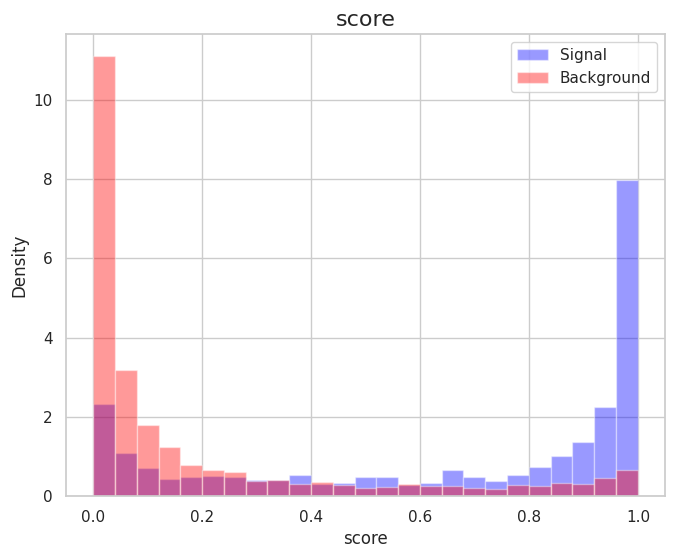

keys ['diboson' 'htautau' 'ttbar' 'ztautau']
keys 2 dict_keys(['diboson', 'htautau', 'ttbar', 'ztautau'])
htautau (30,)


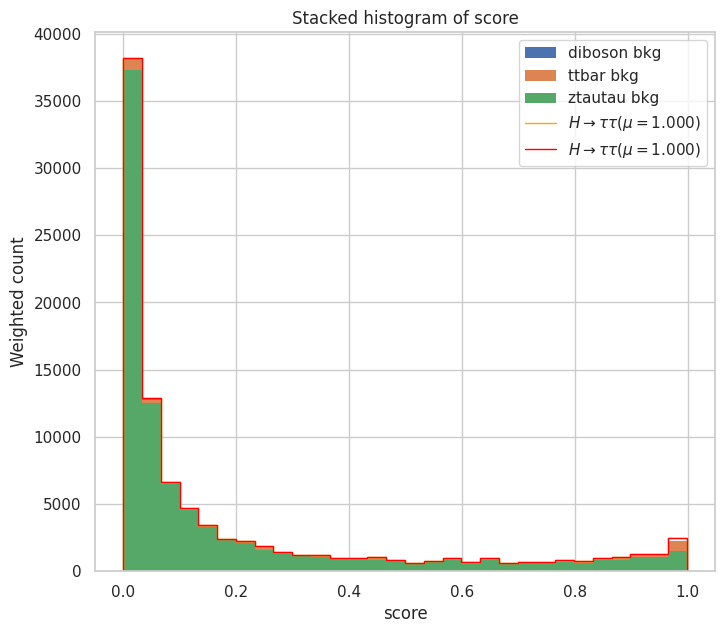

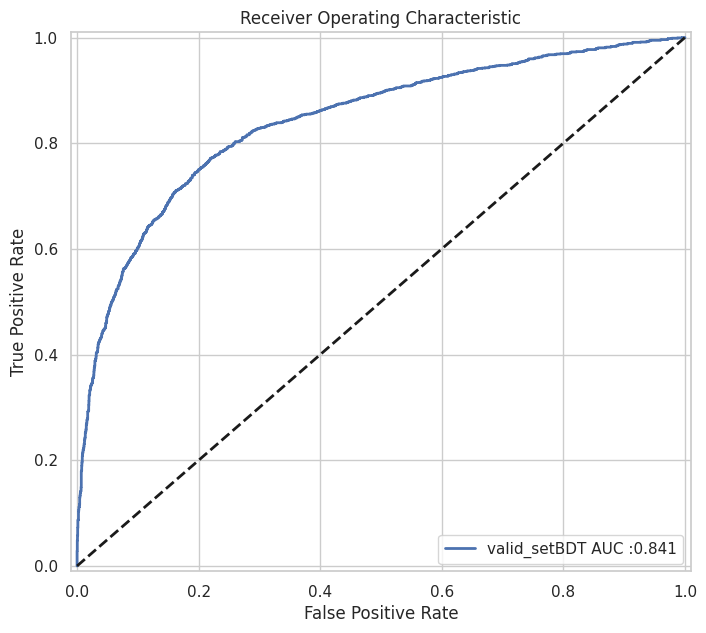

In [7]:
# fit submission
ingestion.fit_submission()

In [8]:
# load test set
data.load_test_set()

In [9]:
test_settings = {
    "systematics": {  # Systematics to use
        "tes": False,  # tau energy scale
        "jes": False,  # jet energy scale
        "soft_met": False,  # soft term in MET
        "ttbar_scale": False,  # W boson scale factor
        "diboson_scale": False,  # Diboson scale factor
        "bkg_scale": False,  # Background scale factor
    },
    "num_pseudo_experiments": 500,  # Number of pseudo-experiments to run per set
    "num_of_sets": 1,  # Number of sets of pseudo-experiments to run
}

RANDOM_SEED = 42

random_state = np.random.RandomState(RANDOM_SEED)
test_settings["ground_truth_mus"] = (
    random_state.uniform(0.1, 3, test_settings["num_of_sets"])
).tolist()
test_settings["jes"] = 1.03
random_settings_file = os.path.join(output_dir, "test_settings.json")
with open(random_settings_file, "w") as f:
    json.dump(test_settings, f)

In [10]:
# predict submission
ingestion.predict_submission(test_settings)

Test Results:  {'mu_hat': np.float64(1.107371179314836), 'del_mu_stat': np.float64(0.27242867769780943), 'del_mu_sys': np.float64(0.0), 'del_mu_tot': np.float64(0.27242867769780943)}
Test Results:  {'mu_hat': np.float64(1.5579621789711777), 'del_mu_stat': np.float64(0.27242867769780943), 'del_mu_sys': np.float64(0.0), 'del_mu_tot': np.float64(0.27242867769780943)}
Test Results:  {'mu_hat': np.float64(1.05958122480583), 'del_mu_stat': np.float64(0.27242867769780943), 'del_mu_sys': np.float64(0.0), 'del_mu_tot': np.float64(0.27242867769780943)}
Test Results:  {'mu_hat': np.float64(0.9981369975799653), 'del_mu_stat': np.float64(0.27242867769780943), 'del_mu_sys': np.float64(0.0), 'del_mu_tot': np.float64(0.27242867769780943)}
Test Results:  {'mu_hat': np.float64(1.4851393911479305), 'del_mu_stat': np.float64(0.27242867769780943), 'del_mu_sys': np.float64(0.0), 'del_mu_tot': np.float64(0.27242867769780943)}
Test Results:  {'mu_hat': np.float64(1.2621196034392361), 'del_mu_stat': np.float64

In [11]:
ingestion.process_results_dict()
# save result
ingestion.save_result(output_dir)

In [12]:
from HiggsML.score import Scoring

[✔]


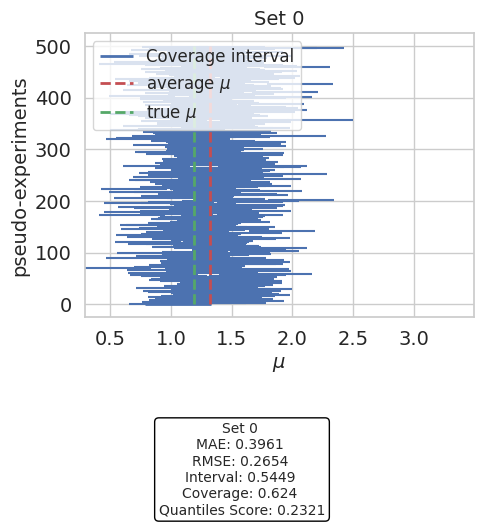

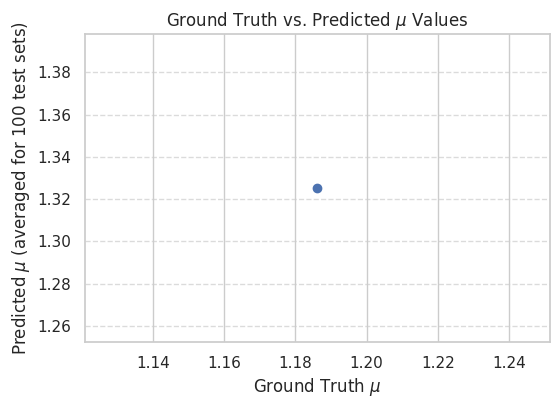

In [13]:
# Initialize Score
score = Scoring()
score.load_ingestion_results(prediction_dir=output_dir, score_dir=output_dir)
# Compute Score
score.compute_scores(test_settings)

from HiggsML.visualization import visualize_scatter

# Visualize scatter plot of ground truth mu and predicted mu
visualize_scatter(
    ingestion_result_dict=ingestion.results_dict,
    ground_truth_mus=test_settings["ground_truth_mus"],
)

In [14]:
!python -m HiggsML.score --prediction $output_dir --output $output_dir

############################################
### Scoring Program
############################################

/content/Higgs_collaborations/sample_result_submission/test_settings.json
2026-06-05 08:39:11,389 - HiggsML.score        - INFO     - Reading ingestion duration from /content/Higgs_collaborations/sample_result_submission/ingestion_duration.json
2026-06-05 08:39:11,389 - HiggsML.score        - WARNING  - File /content/Higgs_collaborations/sample_result_submission/ingestion_duration.json not found. Setting ingestion duration to 0.
/content/Higgs_collaborations/sample_result_submission
2026-06-05 08:39:11,391 - HiggsML.score        - INFO     - Read ingestion results from /content/Higgs_collaborations/sample_result_submission
2026-06-05 08:39:11,391 - HiggsML.score        - INFO     - Computing scores
[✔]
rmse     0.2654
mae     0.3961
interval     0.5449
coverage     0.624
quantiles_score     0.2321
ingestion_duration     0
2026-06-05 08:39:13,169 - HiggsML.score        - INFO  

In [15]:
from HiggsML.systematics import systematics
from HiggsML.datasets import download_dataset

"""Index(['PRI_lep_pt', 'PRI_lep_eta', 'PRI_lep_phi', 'PRI_had_pt', 'PRI_had_eta',
       'PRI_had_phi', 'PRI_jet_leading_pt', 'PRI_jet_leading_eta',
       'PRI_jet_leading_phi', 'PRI_jet_subleading_pt',
       'PRI_jet_subleading_eta', 'PRI_jet_subleading_phi', 'PRI_n_jets',
       'PRI_jet_all_pt', 'PRI_met', 'PRI_met_phi', 'weights',
       'detailed_labels', 'labels', 'DER_mass_transverse_met_lep',
       'DER_mass_vis', 'DER_pt_h', 'DER_deltaeta_jet_jet', 'DER_mass_jet_jet',
       'DER_prodeta_jet_jet', 'DER_deltar_had_lep', 'DER_pt_tot', 'DER_sum_pt',
       'DER_pt_ratio_lep_had', 'DER_met_phi_centrality',
       'DER_lep_eta_centrality'],
      dtype='str')"""

# Charger les données normales
data_normal = download_dataset(
    "blackSwan_data"
)   # votre dataset de base

data_normal.load_train_set()
data_train = data_normal.get_train_set()


--- Score Distribution for JES-varied Data (data_with_JES, JES=0.97) ---


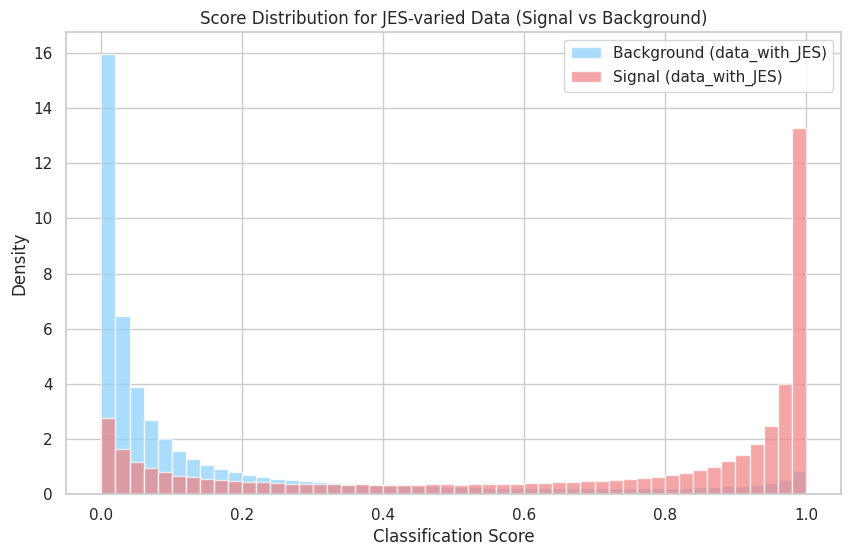


--- Score Distribution for JES-varied Data (data_with_JES, JES=0.97) ---


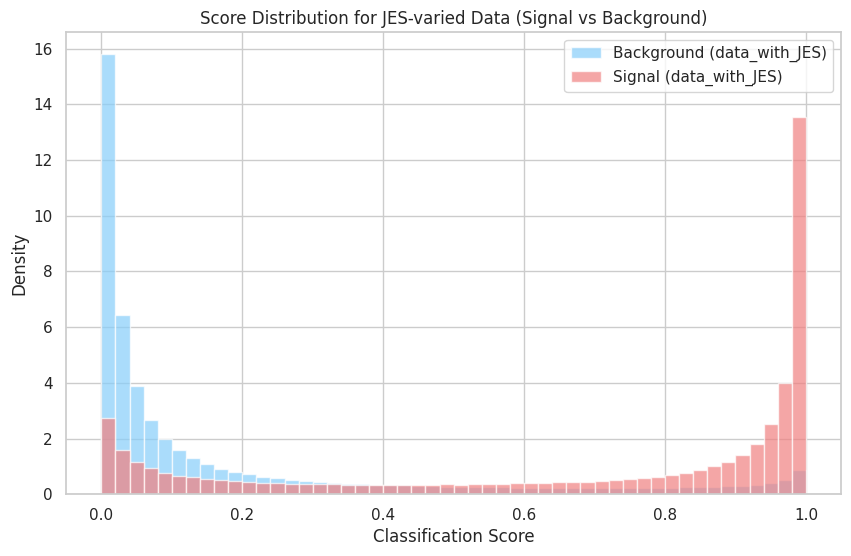


--- Score Distribution for JES-varied Data (data_with_JES, JES=0.97) ---


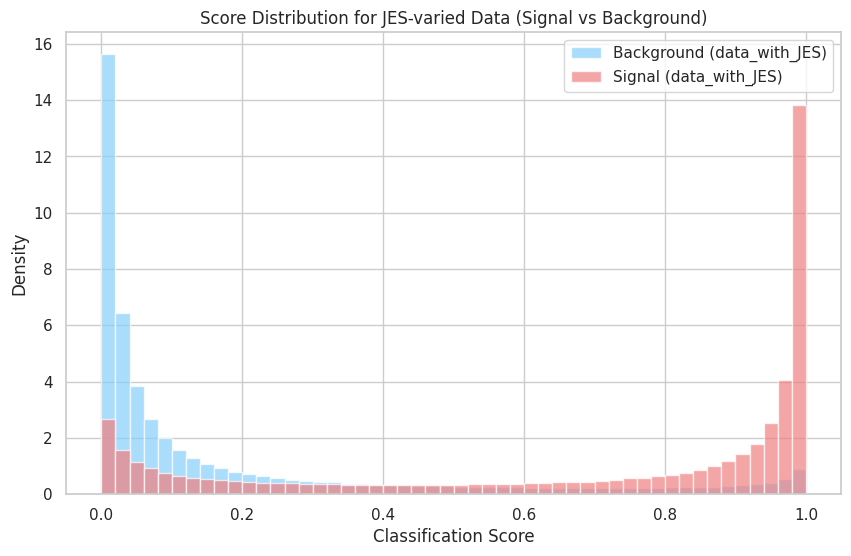


--- Score Distribution for JES-varied Data (data_with_JES, JES=0.97) ---


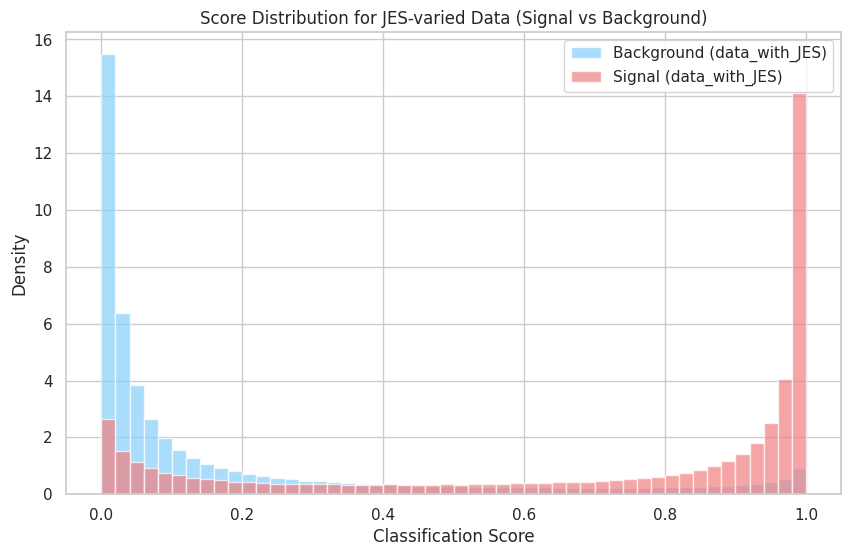


--- Score Distribution for JES-varied Data (data_with_JES, JES=0.97) ---


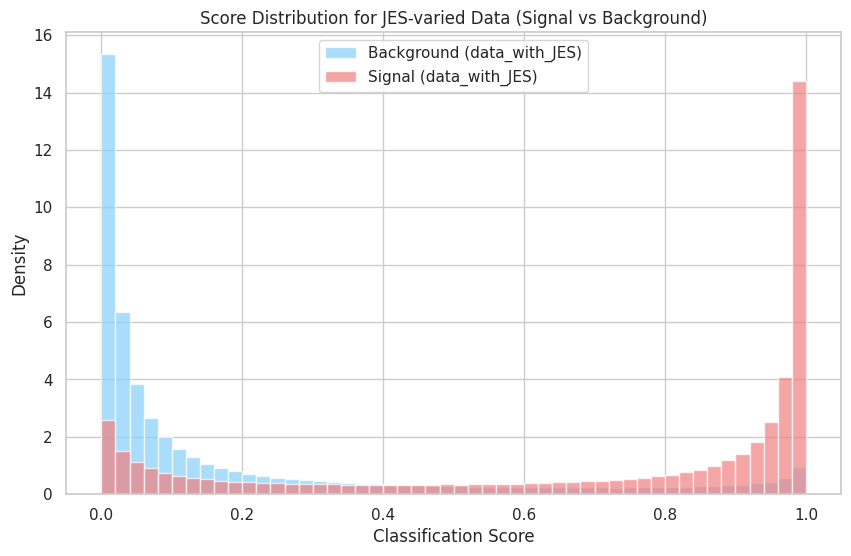

In [16]:
L = np.linspace(0.97,1.03,5)
for jesval in L:
  data_with_JES = systematics(
      data_train,
      jes=jesval  # variation de jes
  )
  import matplotlib.pyplot as plt

  print("\n--- Score Distribution for JES-varied Data (data_with_JES, JES=0.97) ---")

  # Get the feature columns (assuming they are all columns except 'weights', 'labels', 'detailed_labels')
  non_feature_cols = ['weights', 'labels', 'detailed_labels']
  feature_cols = [col for col in data_with_JES.columns if col not in non_feature_cols]

  # Get raw prediction scores for data_with_JES from the BDT model (ingestion.model.model.predict)
  # Assuming predict returns probabilities/scores directly.
  raw_scores_jes = ingestion.model.model.predict(data_with_JES[feature_cols])

  signal_scores_jes = raw_scores_jes[data_with_JES['labels'] == 1]
  background_scores_jes = raw_scores_jes[data_with_JES['labels'] == 0]

  # Plot the distributions for data_with_JES
  plt.figure(figsize=(10, 6))
  plt.hist(background_scores_jes, bins=50, alpha=0.7, label='Background (data_with_JES)', color='lightskyblue', density=True)
  plt.hist(signal_scores_jes, bins=50, alpha=0.7, label='Signal (data_with_JES)', color='lightcoral', density=True)
  plt.title('Score Distribution for JES-varied Data (Signal vs Background)')
  plt.xlabel('Classification Score')
  plt.ylabel('Density')
  plt.legend()
  plt.grid(True)
  plt.show()

In [17]:
def varpar(par,parnormal,listevalpar,intervalscore):
  c=intervalscore[0]
  d=intervalscore[1]
  kwargs = {par: parnormal}
  data_with_PAR = systematics(
    data_train,
    **kwargs # variation du paramètre
  )

  # Get the feature columns (assuming they are all columns except 'weights', 'labels', 'detailed_labels')
  non_feature_cols = ['weights', 'labels', 'detailed_labels']
  feature_cols = [col for col in data_with_PAR.columns if col not in non_feature_cols]

    # Get raw prediction scores for data_with_JES from the BDT model (ingestion.model.model.predict)
    # Assuming predict returns probabilities/scores directly.
  raw_scores_par = ingestion.model.model.predict(data_with_PAR[feature_cols])

  signal_scores_par = raw_scores_par[data_with_PAR['labels'] == 1]
  background_scores_par = raw_scores_par[data_with_PAR['labels'] == 0]


  s0 = 0
  b0 = 0
  for i in range (len(raw_scores_par)) :
      if data_with_PAR['labels'][i] == 1 and raw_scores_par[i] > c and raw_scores_par[i] <d :
        s0=s0+data_with_PAR['weights'][i]
      if data_with_PAR['labels'][i] == 0 and raw_scores_par[i] > c and raw_scores_par[i] <d :
        b0=b0+data_with_PAR['weights'][i]

  liste_delta_s =[]
  liste_delta_b =[]
  L = listevalpar
  for parval in L:
    kwargs = {par: parval}
    data_with_PAR = systematics(
    data_train,
    **kwargs # variation du paramètre
    )

    # Get the feature columns (assuming they are all columns except 'weights', 'labels', 'detailed_labels')
    non_feature_cols = ['weights', 'labels', 'detailed_labels']
    feature_cols = [col for col in data_with_PAR.columns if col not in non_feature_cols]

    # Get raw prediction scores for data_with_JES from the BDT model (ingestion.model.model.predict)
    # Assuming predict returns probabilities/scores directly.
    raw_scores_par = ingestion.model.model.predict(data_with_PAR[feature_cols])

    signal_scores_tes = raw_scores_par[data_with_PAR['labels'] == 1]
    background_scores_tes = raw_scores_par[data_with_PAR['labels'] == 0]


    s = 0
    b = 0
    for i in range (len(raw_scores_par)) :
      if data_with_PAR['labels'][i] == 1 and raw_scores_par[i] > c and raw_scores_par[i] <d :
        s=s+data_with_PAR['weights'][i]
      if data_with_PAR['labels'][i] == 0 and raw_scores_par[i] > c and raw_scores_par[i] <d :
        b=b+data_with_PAR['weights'][i]
    liste_delta_s.append(s-s0)
    liste_delta_b.append(b-b0)

  plt.plot(L,liste_delta_s,marker='o')
  plt.show()
  plt.plot(L,liste_delta_b,marker='o')
  plt.show()
  return liste_delta_s,liste_delta_b

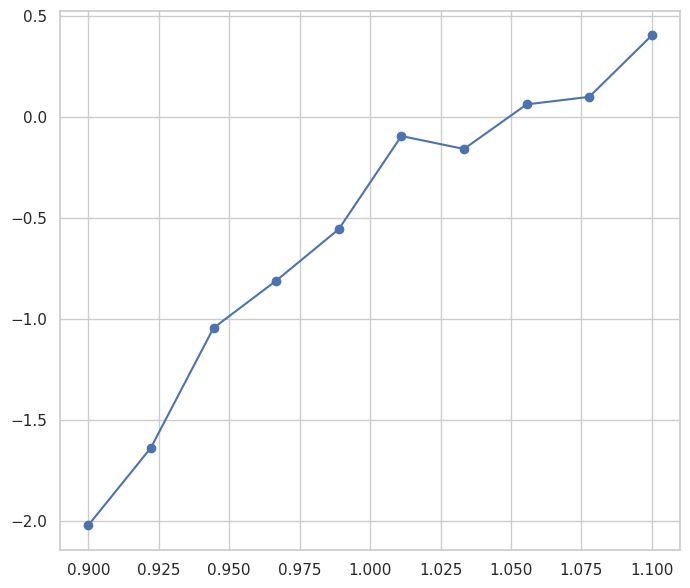

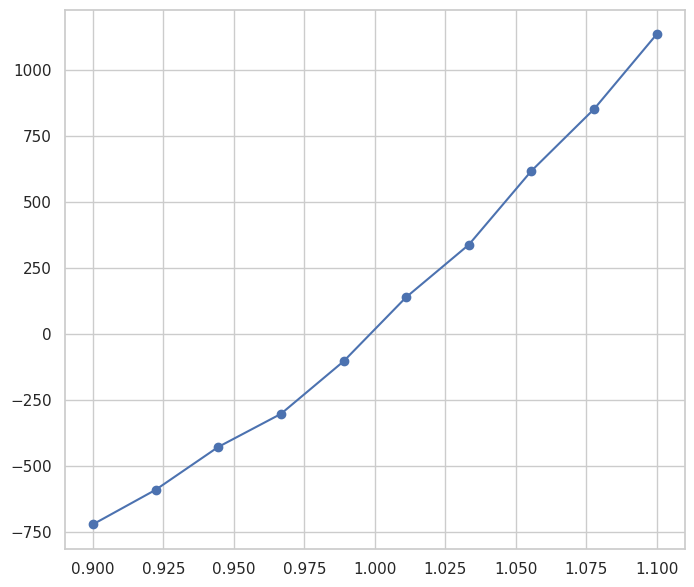

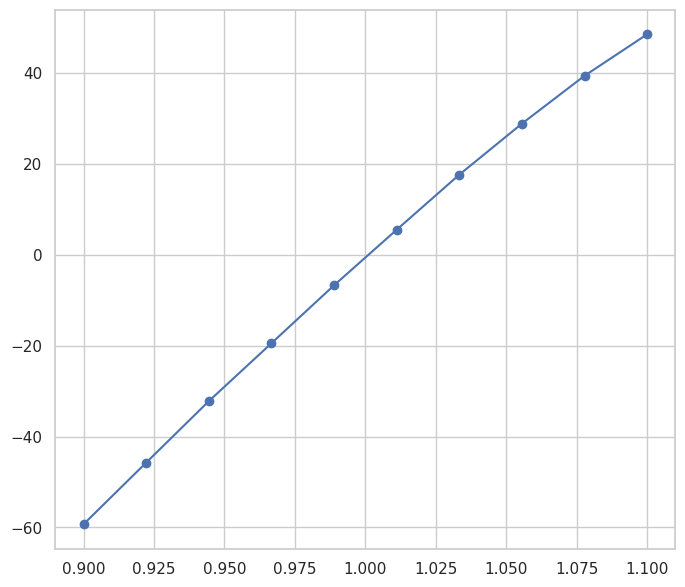

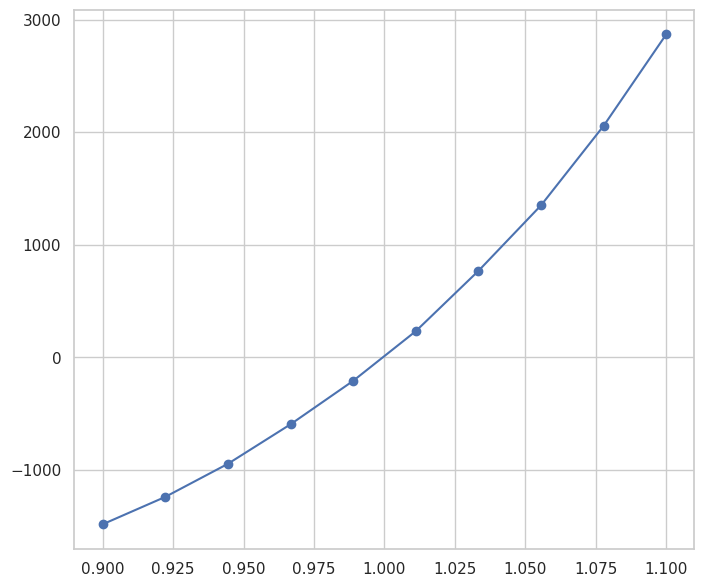

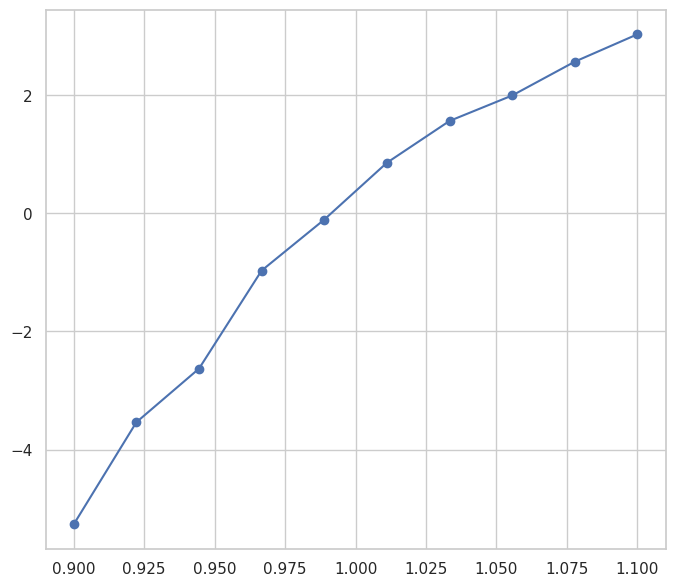

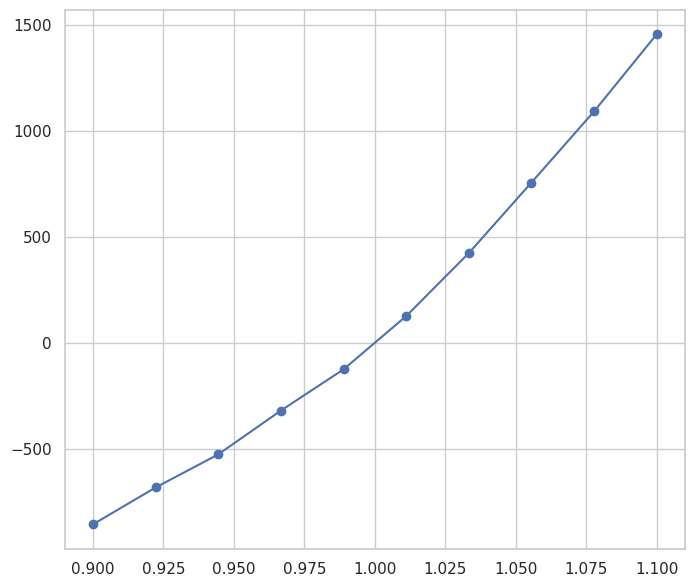

In [18]:
liste_delta_s2,liste_delta_b2 = varpar('tes',1,np.linspace(0.9,1.1,10),[0.7,0.8])
liste_delta_s0,liste_delta_b0 = varpar('tes',1,np.linspace(0.9,1.1,10),[0.9,1])
liste_delta_s1,liste_delta_b1 = varpar('tes',1,np.linspace(0.9,1.1,10),[0.8,0.9])

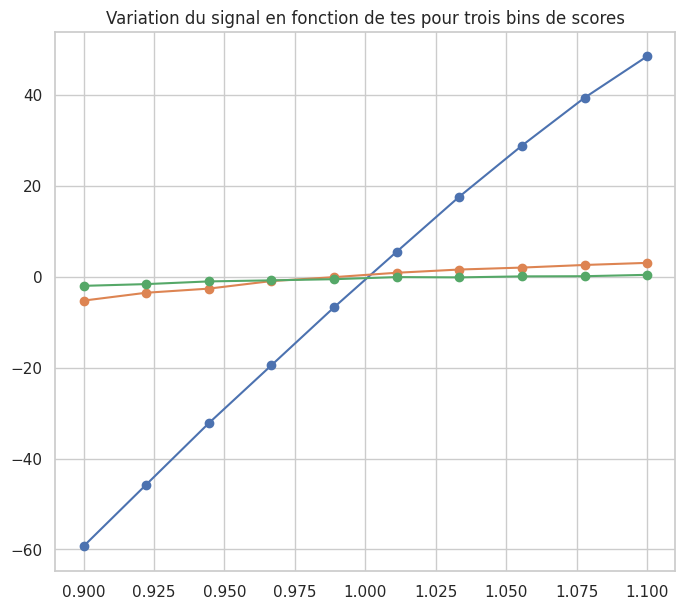

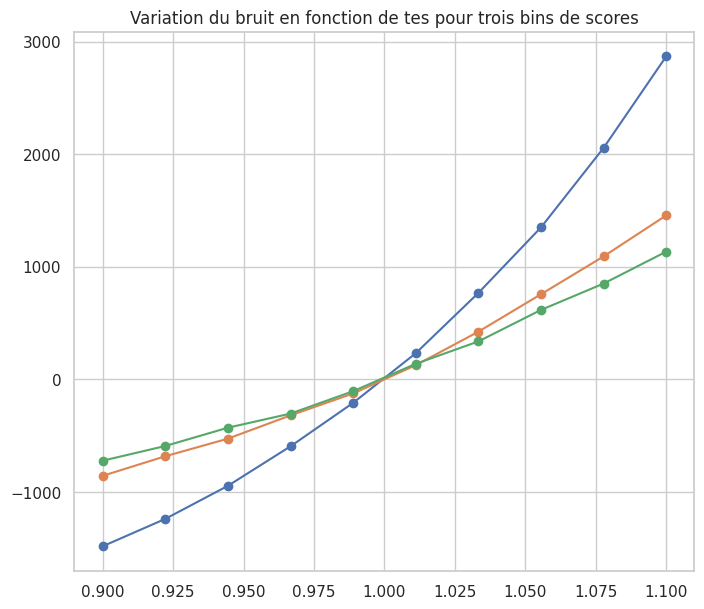

In [19]:
plt.plot(np.linspace(0.9,1.1,10),liste_delta_s0,marker='o')
plt.plot(np.linspace(0.9,1.1,10),liste_delta_s1,marker='o')
plt.plot(np.linspace(0.9,1.1,10),liste_delta_s2,marker='o')
plt.title('Variation du signal en fonction de tes pour trois bins de scores')
plt.show()
plt.plot(np.linspace(0.9,1.1,10),liste_delta_b0,marker='o')
plt.plot(np.linspace(0.9,1.1,10),liste_delta_b1,marker='o')
plt.plot(np.linspace(0.9,1.1,10),liste_delta_b2,marker='o')
plt.title('Variation du bruit en fonction de tes pour trois bins de scores')
plt.show()


In [ ]:
liste_delta_s2,liste_delta_b2 = varpar('jes',1,np.linspace(0.9,1.1,10),[0.7,0.8])
liste_delta_s1,liste_delta_b1 = varpar('jes',1,np.linspace(0.9,1.1,10),[0.8,0.9])
liste_delta_s0,liste_delta_b0 = varpar('jes',1,np.linspace(0.9,1.1,10),[0.9,1])

plt.plot(np.linspace(0.9,1.1,10),liste_delta_s0,marker='o')
plt.plot(np.linspace(0.9,1.1,10),liste_delta_s1,marker='o')
plt.plot(np.linspace(0.9,1.1,10),liste_delta_s2,marker='o')
plt.title('Variation du signal en fonction de jes pour trois bins de scores')
plt.show()
plt.plot(np.linspace(0.9,1.1,10),liste_delta_b0,marker='o')
plt.plot(np.linspace(0.9,1.1,10),liste_delta_b1,marker='o')
plt.plot(np.linspace(0.9,1.1,10),liste_delta_b2,marker='o')
plt.title('Variation du bruit en fonction de jes pour trois bins de scores')
plt.show()

In [ ]:
liste_delta_s2,liste_delta_b2 = varpar('soft_met',0,np.linspace(0,3,10),[0.7,0.8])
liste_delta_s1,liste_delta_b1 = varpar('soft_met',0,np.linspace(0,3,10),[0.8,0.9])
liste_delta_s0,liste_delta_b0 = varpar('soft_met',0,np.linspace(0,3,10),[0.9,1])

plt.plot(np.linspace(0,3,10),liste_delta_s0,marker='o')
plt.plot(np.linspace(0,3,10),liste_delta_s1,marker='o')
plt.plot(np.linspace(0,3,10),liste_delta_s2,marker='o')
plt.title('Variation du signal en fonction de soft_met pour trois bins de scores')
plt.show()
plt.plot(np.linspace(0,3,10),liste_delta_b0,marker='o')
plt.plot(np.linspace(0,3,10),liste_delta_b1,marker='o')
plt.plot(np.linspace(0,3,10),liste_delta_b2,marker='o')
plt.title('Variation du bruit en fonction de soft_met pour trois bins de scores')
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Paramètres des bins et des variations
score_bins_centers = (l[:-1] + l[1:]) / 2
jes_values = np.linspace(0.9, 1.1, 10)
cmap = plt.cm.get_cmap('coolwarm', len(jes_values))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Plot pour a[i] (Signal)
for j in range(len(jes_values)):
    # On extrait le j-ème élément de chaque sous-liste a[i]
    weights_per_bin_a = [a[i][j] for i in range(len(a))]
    ax1.plot(score_bins_centers, weights_per_bin_a, marker='o', color=cmap(j), label=f'jes={jes_values[j]:.2f}')

ax1.set_title('Poids du Signal (a) par Bin de Score')
ax1.set_xlabel('Score moyen du bin')
ax1.set_ylabel('Variation du poids (s - s0)')
ax1.grid(True, linestyle='--', alpha=0.6)

# Plot pour b[i] (Bruit)
for j in range(len(jes_values)):
    # On extrait le j-ème élément de chaque sous-liste b[i]
    weights_per_bin_b = [b[i][j] for i in range(len(b))]
    ax2.plot(score_bins_centers, weights_per_bin_b, marker='o', color=cmap(j), label=f'jes={jes_values[j]:.2f}')

ax2.set_title('Poids du Bruit (b) par Bin de Score')
ax2.set_xlabel('Score moyen du bin')
ax2.set_ylabel('Variation du poids (b - b0)')
ax2.grid(True, linestyle='--', alpha=0.6)

# Légende unique pour la figure
handles, labels = ax1.get_legend_handles_labels()
fig.legend(handles, labels, loc='center right', title='Valeurs JES')
plt.tight_layout(rect=[0, 0, 0.9, 1])
plt.show()